In [20]:
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

from qiskit import transpile
from qiskit.circuit import Parameter,ParameterExpression
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import FakeMumbaiV2
from qiskit.converters import circuit_to_dag, dag_to_circuit

import sys
sys.path.append("../")
from clapton.clapton import claptonize
from clapton.circuit_manipulation import transform_to_allowed_gates,qiskit_to_stim, modify_circuit, multi_angle_qaoa_circuit, transform_qiskit_to_stim,generate_qiskit_param_map
from testing_scripts.graphs_utils import generate_random_complete_graph,generate_k_regular_graph,compute_optimal_max_cut,build_max_cut_paulis
from testing_scripts.qaoa_utils import QAOASolver

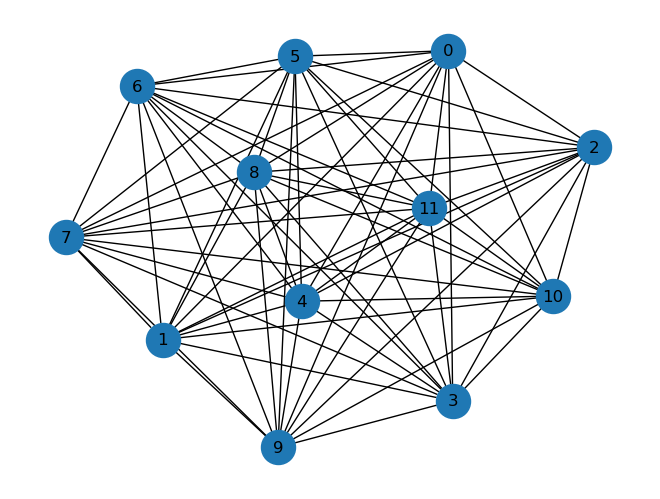

In [21]:
n = 12
k=3
# G = generate_k_regular_graph(num_vertices=n, k=k, weighted=True,seed=True)
G=generate_random_complete_graph(num_vertices=n, weighted=True, seed=True)
draw_graph(G, node_size=600, with_labels=True)

In [22]:
# Optimal Maxcut Calculation 
optimal_max_cut_val = compute_optimal_max_cut(G)
print(f"Optimal Max Cut Value : {optimal_max_cut_val}")

Optimal Max Cut Value : 239


In [23]:
max_cut_paulis = build_max_cut_paulis(G)

cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
print("Cost Function Hamiltonian:", cost_hamiltonian)

Cost Function Hamiltonian: SparsePauliOp(['IIIIIIIIIIZZ', 'IIIIIIIIIZIZ', 'IIIIIIIIZIIZ', 'IIIIIIIZIIIZ', 'IIIIIIZIIIIZ', 'IIIIIZIIIIIZ', 'IIIIZIIIIIIZ', 'IIIZIIIIIIIZ', 'IIZIIIIIIIIZ', 'IZIIIIIIIIIZ', 'ZIIIIIIIIIIZ', 'IIIIIIIIIZZI', 'IIIIIIIIZIZI', 'IIIIIIIZIIZI', 'IIIIIIZIIIZI', 'IIIIIZIIIIZI', 'IIIIZIIIIIZI', 'IIIZIIIIIIZI', 'IIZIIIIIIIZI', 'IZIIIIIIIIZI', 'ZIIIIIIIIIZI', 'IIIIIIIIZZII', 'IIIIIIIZIZII', 'IIIIIIZIIZII', 'IIIIIZIIIZII', 'IIIIZIIIIZII', 'IIIZIIIIIZII', 'IIZIIIIIIZII', 'IZIIIIIIIZII', 'ZIIIIIIIIZII', 'IIIIIIIZZIII', 'IIIIIIZIZIII', 'IIIIIZIIZIII', 'IIIIZIIIZIII', 'IIIZIIIIZIII', 'IIZIIIIIZIII', 'IZIIIIIIZIII', 'ZIIIIIIIZIII', 'IIIIIIZZIIII', 'IIIIIZIZIIII', 'IIIIZIIZIIII', 'IIIZIIIZIIII', 'IIZIIIIZIIII', 'IZIIIIIZIIII', 'ZIIIIIIZIIII', 'IIIIIZZIIIII', 'IIIIZIZIIIII', 'IIIZIIZIIIII', 'IIZIIIZIIIII', 'IZIIIIZIIIII', 'ZIIIIIZIIIII', 'IIIIZZIIIIII', 'IIIZIZIIIIII', 'IIZIIZIIIIII', 'IZIIIZIIIIII', 'ZIIIIZIIIIII', 'IIIZZIIIIIII', 'IIZIZIIIIIII', 'IZIIZIIIIIII', 'ZIIIZIIIIIII'

In [24]:
reps = 5
circuit = multi_angle_qaoa_circuit(n,G ,reps)
# circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)
circuit.num_parameters

390

In [25]:
maxcut_qaoa = QAOASolver(cost_hamiltonian,circuit)
maxcut_qaoa.prepare_circuit()

In [26]:
#Run CAFQA process 
maxcut_qaoa.run_CAFQA(n_gens=20)

STARTING ROUND 0


started GA at id 1 with 1 procs

started GA at id 2 with 1 procs

started GA at id 3 with 1 procs

GA parameters used for this experiment:
  num_generations=10
  num_parents_mating=20
  population_size=100
  num_genes=390
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5
GA parameters used for this experiment:
  num_generations=10
  num_parents_mating=20
  population_size=100
  num_genes=390
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5GA parameters used for this experiment:
  num_generations=10
  num_parents_mating=20
  population_size=100
  num_genes=390
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9


In [27]:
maxcut_qaoa.energy_best

np.float64(-10.0)

In [28]:
maxcut_qaoa.evaluate_exact_energy()

Exact Energy from Eigensolver: -93.99999999999999


np.float64(-93.99999999999999)

In [29]:
ordered_params = [param.name for param in maxcut_qaoa.pcirc.parameters]
angle_multipliers = [-np.pi/4 if 'gamma' in param else np.pi/4 for param in ordered_params]

random_params = np.random.random(len(ordered_params))
cafqa_params = [param * (np.pi/2) for param,multiplier in zip(maxcut_qaoa.ks_best,angle_multipliers)] #This has to be in the order we come across the gates.

In [30]:
maxcut_qaoa.evaluate_energy(maxcut_qaoa.pcirc,cost_hamiltonian,cafqa_params,noise=False)

array(-9.94287109)

In [ ]:
cafqa_result, cafqa_obj_values =maxcut_qaoa.run_qaoa(cafqa_params,max_iters=500,opt="SPSA")
random_result, random_obj_values =maxcut_qaoa.run_qaoa(random_params,max_iters=500,opt="SPSA")

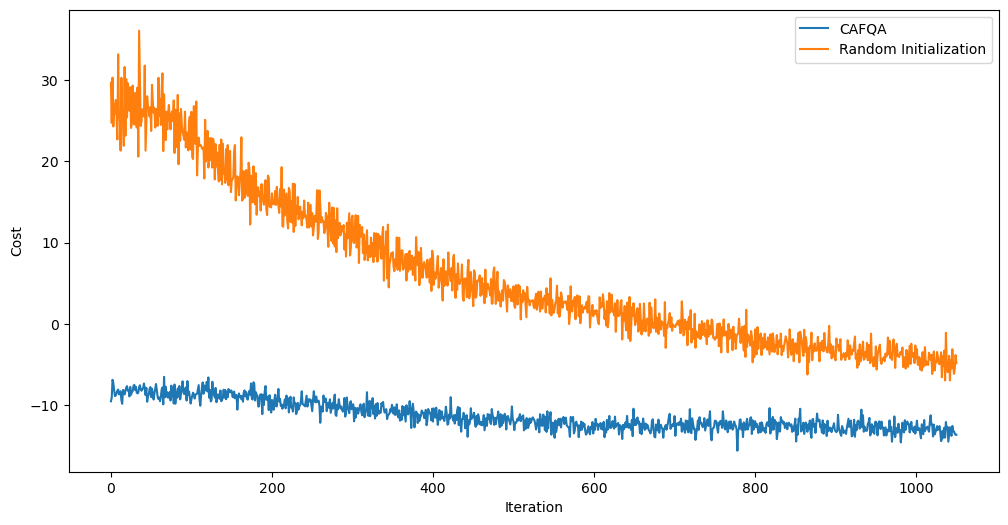

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(cafqa_obj_values, label="CAFQA")
plt.plot(random_obj_values, label="Random Initialization")
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Cost")

plt.show()

In [14]:
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)
vanilla_teague = QAOASolver(cost_hamiltonian,circuit.decompose().decompose())
vanilla_teague.vanilla = True

In [15]:
import os
init_random_params = np.random.random(circuit.num_parameters)
res,obj_values=vanilla_teague.run_qaoa(init_random_params, max_iters=1000)
results_dict = {
    "vanilla_fin_energy": res,
    "vanilla_iteration_values": obj_values,
}

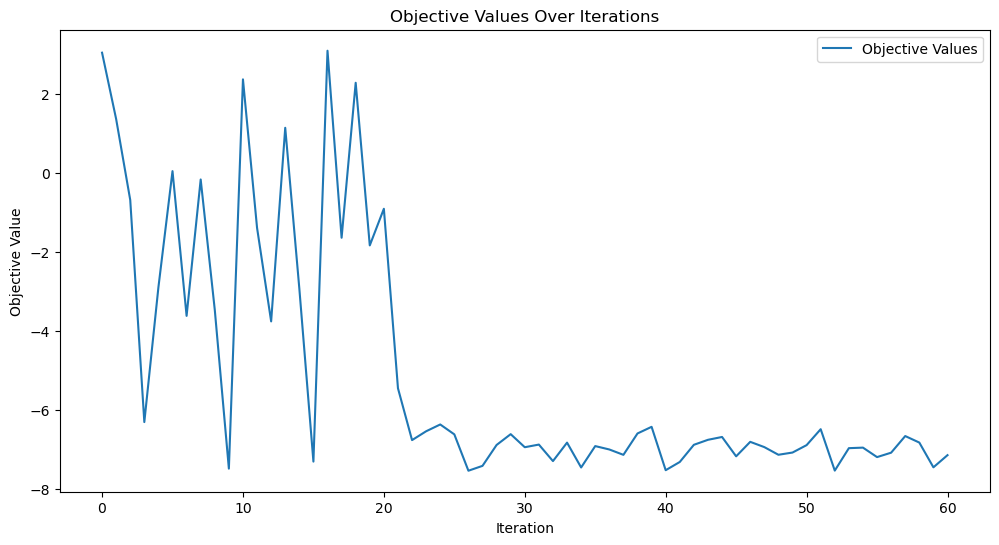

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(obj_values, label="Objective Values")
plt.xlabel("Iteration")
plt.ylabel("Objective Value")
plt.title("Objective Values Over Iterations")
plt.legend()
plt.show()

In [17]:
optimized_circuit = maxcut_qaoa.pcirc.assign_parameters(random_result.x)
from qiskit.quantum_info import Statevector
state = Statevector(optimized_circuit).probabilities_dict(decimals=3)
len(state)

60

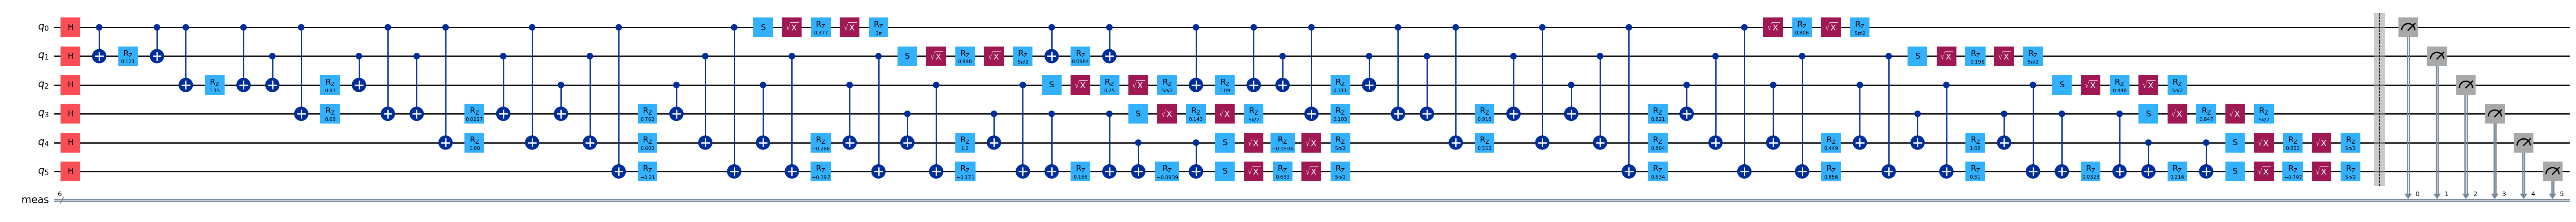

In [18]:
optimized_circuit.measure_all()
optimized_circuit.draw('mpl', fold=False, idle_wires=False)

In [19]:
sampler = Sampler(mode=maxcut_qaoa.backend)
sampler.options.default_shots = 10000

pub= (optimized_circuit, )
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val/shots for key, val in counts_int.items()}
final_distribution_bin = {key: val/shots for key, val in counts_bin.items()}
print(final_distribution_int)
len(counts_int),len(counts_bin)

any_zero = any(value == 0 for value in final_distribution_int.values())
print("Is there any value equal to 0 in final_distribution_int?", any_zero)

{16: 0.0083, 3: 0.0077, 53: 0.0194, 56: 0.0674, 36: 0.0113, 40: 0.0447, 25: 0.0115, 30: 0.0191, 15: 0.0693, 37: 0.0422, 7: 0.0673, 62: 0.0092, 49: 0.0121, 42: 0.0146, 41: 0.0871, 10: 0.0189, 26: 0.041, 54: 0.0112, 22: 0.0928, 38: 0.0101, 28: 0.0044, 29: 0.0083, 0: 0.0012, 11: 0.0208, 23: 0.0447, 33: 0.0182, 27: 0.013, 50: 0.0039, 48: 0.0704, 21: 0.0144, 17: 0.0006, 60: 0.0088, 14: 0.0114, 5: 0.0027, 9: 0.0091, 1: 0.0099, 34: 0.0071, 52: 0.0219, 13: 0.006, 2: 0.0055, 45: 0.0025, 4: 0.0028, 57: 0.0075, 6: 0.0061, 35: 0.0042, 31: 0.0027, 32: 0.0023, 59: 0.0029, 58: 0.0033, 55: 0.001, 43: 0.0007, 47: 0.0046, 61: 0.0063, 46: 0.0006, 51: 0.0006, 20: 0.0007, 8: 0.0008, 63: 0.0007, 39: 0.0001, 18: 0.001, 12: 0.0008, 44: 0.0002, 24: 0.0001}
Is there any value equal to 0 in final_distribution_int? False


In [20]:
# auxiliary functions to sample most likely bitstring
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]

keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, len(G))
most_likely_bitstring.reverse()

print("Result bitstring:", most_likely_bitstring)

Result bitstring: [0, 1, 1, 0, 1, 0]


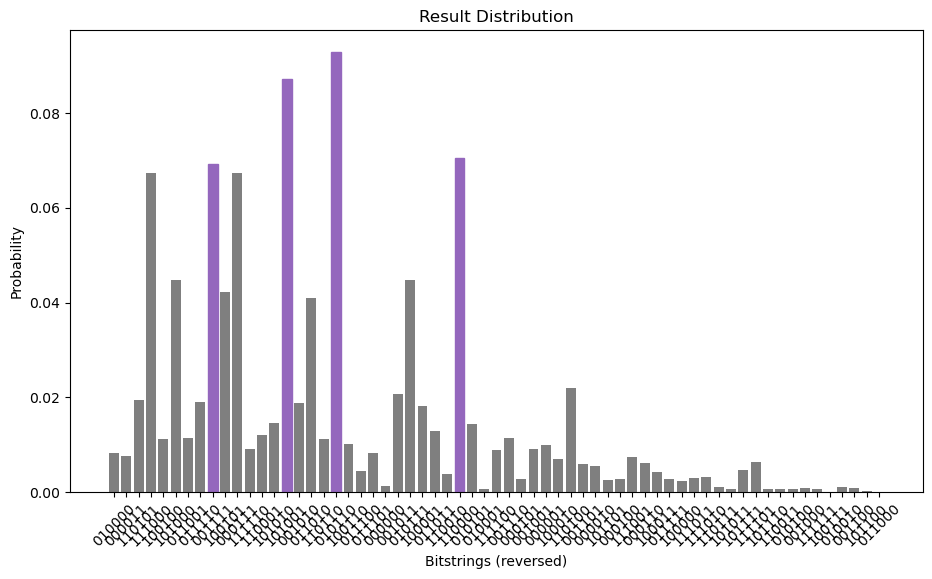

In [21]:
matplotlib.rcParams.update({"font.size": 10})
final_bits = final_distribution_bin
values = np.abs(list(final_bits.values()))
top_4_values = sorted(values, reverse=True)[:4]
positions = []
for value in top_4_values:
    positions.append(np.where(values == value)[0][0])
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=45)
plt.title("Result Distribution")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Probability")
ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:grey")
for p in positions:
    ax.get_children()[int(p)].set_color("tab:purple")

# plt.savefig('../plots/CAFQA_States_8_qubit_Barplot.png', dpi=800, bbox_inches='tight')
plt.show()

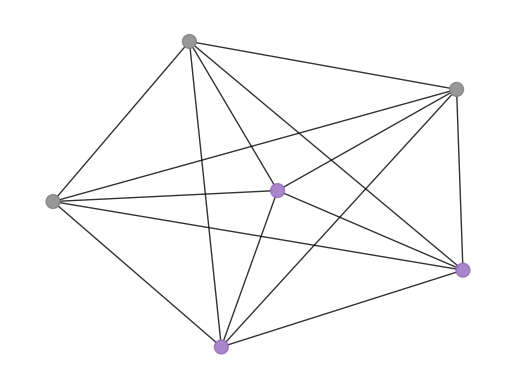

In [22]:
# auxiliary function to plot graphs
def plot_result(G, x):
    colors = ["tab:grey" if i == 0 else "tab:purple" for i in x]
    pos, default_axes = rx.spring_layout(G), plt.axes(frameon=True)
    rx.visualization.mpl_draw(G, node_color=colors, node_size=100, alpha=0.8, pos=pos)

plot_result(G, most_likely_bitstring)

In [23]:
from typing import Sequence
def evaluate_sample(x: Sequence[int], graph: rx.PyGraph) -> float:
    assert len(x) == len(list(graph.nodes())), "The length of x must coincide with the number of nodes in the graph."
    return sum(w*(x[u] * (1 - x[v]) + x[v] * (1 - x[u])) for u, v,w in list(graph.weighted_edge_list()))


cut_value= evaluate_sample(most_likely_bitstring, G)
print('The value of the cut is:', cut_value)

The value of the cut is: 58


In [24]:
top_4_values

[np.float64(0.0928),
 np.float64(0.0871),
 np.float64(0.0704),
 np.float64(0.0693)]